# Práctica 06: Clasificación de los Pacientes con Riesgo de  Infarto Cardio Vascular en el Estado de Puebla

**Proyecto:** Clasificación de los Pacientes con Riesgo de Infarto Cardio Vascular en el Estado de Puebla

Este notebook desarrolla la Práctica 02: se parte del dataset clínico simulado (5,000 pacientes) al que se le agregaron coordenadas GPS (latitud/longitud) generadas dentro de los polígonos reales de cada municipio de Puebla. A partir de ahí se realiza:

1. Revisión y validación del dataset (estructura, nulos, geoposicionamiento)
2. Carga de polígonos municipales con GeoPandas
3. Unión espacial (spatial join) para obtener `municipio_objetivo`
4. Análisis y visualización de la distribución geográfica de pacientes
5. Mapas interactivos: puntos, heatmap y coroplético (Folium)
6. Preparación del dataset de modelado (**solo latitud/longitud como variables predictoras**)
7. Entrenamiento de modelos supervisados de clasificación (KNN, Árbol de Decisión / Random Forest, SVM)
8. Evaluación, matriz de confusión y análisis de errores
9. Predicción sobre nuevas coordenadas y comparación contra la asignación espacial
10. Conclusiones

> **Nota sobre el trabajo en equipo:** en la práctica original, cada integrante genera su propio dataset de 5,000 pacientes y el equipo los fusiona en un dataset grupal de 20,000–30,000 registros. Este notebook está construido para trabajar con **un** dataset individual; si tu equipo ya fusionó los datasets, simplemente reemplaza el archivo cargado en la sección 1 por el CSV grupal (debe conservar las mismas columnas, incluyendo `Latitud` y `Longitud`) y el resto del notebook funcionará igual.

## 1. Carga del dataset y verificación de estructura

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('dataset_riesgo_infarto_puebla_5000.csv', encoding='utf-8-sig')
print(f"Dimensiones: {df.shape[0]} pacientes x {df.shape[1]} columnas")
df.head()


Dimensiones: 5000 pacientes x 27 columnas


,ID_Paciente,Nombre,Apellido,Sexo,Edad,Municipio,Latitud,Longitud,Peso_kg,Estatura_m,IMC,Presion_Sistolica,Presion_Diastolica,Frecuencia_Cardiaca,Temperatura,Saturacion_O2,Glucosa,Colesterol,Trigliceridos,Fuma,Alcohol,Actividad_Fisica,Diabetes,Hipertension,Obesidad,Diagnostico,Riesgo
0,1,Juan,Pérez,Masculino,21,Tehuacán,18.511587,-97.267586,76.3,1.75,24.91,135,75,68,36.5,92,127,165,258,Sí,Sí,Media,Sí,No,No,Paciente sano,Bajo
1,2,Carlos,Hernández,Masculino,87,San Pedro Cholula,19.120649,-98.305600,96.3,1.77,30.74,153,74,103,36.7,93,184,280,141,Sí,Sí,Media,Sí,Sí,Sí,Obesidad,Alto
2,3,José,Sánchez,Femenino,30,San Andrés Cholula,19.051854,-98.207348,65.2,1.58,26.12,145,82,108,37.4,97,137,141,256,No,Sí,Alta,Sí,Sí,No,Gastritis,Medio
3,4,Laura,González,Masculino,26,Atlixco,18.969397,-98.467407,87.2,1.83,26.04,105,74,78,36.8,96,144,150,288,Sí,Sí,Baja,Sí,No,No,Paciente sano,Bajo
4,5,Juan,López,Masculino,39,Puebla,18.939616,-98.163867,84.5,1.69,29.59,168,75,106,36.7,96,111,248,167,No,Sí,Media,No,Sí,No,Paciente sano,Bajo


In [2]:
# Confirmar columnas de geoposicionamiento
assert {'Latitud', 'Longitud', 'Municipio'}.issubset(df.columns), "Faltan columnas de geoposicionamiento"
print("Columnas de geoposicionamiento presentes: Latitud, Longitud, Municipio")
df[['Latitud', 'Longitud']].describe()


Columnas de geoposicionamiento presentes: Latitud, Longitud, Municipio


,Latitud,Longitud
count,5000.000000,5000.000000
mean,19.271120,-97.964230
std,0.515162,0.353980
min,18.401012,-98.468618
25%,18.992329,-98.207852
50%,19.098043,-98.041778
75%,19.876689,-97.910925
max,20.286648,-97.190656


### 1.1 Validar número total de registros (dataset grupal)

In [3]:
# Si trabajas con el dataset grupal fusionado, aquí deberías ver ~ (num_integrantes x 5000) registros
print(f"Total de registros: {len(df)}")
print(f"Número de integrantes esperado (aprox.): {len(df) / 5000:.1f}")


Total de registros: 5000
Número de integrantes esperado (aprox.): 1.0


### 1.2 Duplicados y valores nulos

In [4]:
print("Registros duplicados (todas las columnas):", df.duplicated().sum())
print("IDs de paciente duplicados:", df['ID_Paciente'].duplicated().sum())
print("\nNulos en columnas de geoposicionamiento:")
print(df[['Latitud', 'Longitud']].isnull().sum())

# Eliminar duplicados si los hubiera (por seguridad, ej. tras fusionar equipos)
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nRegistros eliminados por duplicado: {antes - len(df)}")


Registros duplicados (todas las columnas): 0
IDs de paciente duplicados: 0

Nulos en columnas de geoposicionamiento:
Latitud     0
Longitud    0
dtype: int64

Registros eliminados por duplicado: 0


### 1.3 Validar rangos de coordenadas (deben caer dentro del territorio de Puebla)

In [5]:
# Bounding box aproximado del estado de Puebla
LAT_MIN, LAT_MAX = 17.8, 20.9
LON_MIN, LON_MAX = -99.1, -96.5

fuera_de_rango = df[~df['Latitud'].between(LAT_MIN, LAT_MAX) | ~df['Longitud'].between(LON_MIN, LON_MAX)]
print(f"Registros con coordenadas fuera del rango esperado de Puebla: {len(fuera_de_rango)}")

if len(fuera_de_rango) > 0:
    df = df.drop(fuera_de_rango.index).reset_index(drop=True)
    print("Registros fuera de rango eliminados.")


Registros con coordenadas fuera del rango esperado de Puebla: 0


In [6]:
# Copia completa (con todas las etiquetas originales) para consulta y validación,
# NO se usará para entrenar el modelo.
df_referencia = df.copy()
print("Copia de referencia guardada en 'df_referencia' (incluye Municipio, Diagnostico, Riesgo, etc.)")


Copia de referencia guardada en 'df_referencia' (incluye Municipio, Diagnostico, Riesgo, etc.)


## 2. Carga de polígonos municipales con GeoPandas

Se utilizan los límites municipales oficiales del estado de Puebla (213 municipios, fuente: CONABIO / repositorio público `angelnmara/geojson`).

In [7]:
municipios_gdf = gpd.read_file('puebla_municipios.geojson')[['NAME_2', 'geometry']]
municipios_gdf = municipios_gdf.rename(columns={'NAME_2': 'municipio_poligono'})
print(f"Polígonos municipales cargados: {len(municipios_gdf)}")
print(f"Sistema de referencia (CRS): {municipios_gdf.crs}")
municipios_gdf.head()


Polígonos municipales cargados: 213
Sistema de referencia (CRS): EPSG:4326


,municipio_poligono,geometry
0,Acajete,"POLYGON ((-97.75841 19.14529, -97.75938 19.142..."
1,Acateno,"POLYGON ((-97.15316 20.0896, -97.15682 20.0905..."
2,Acatlán,"POLYGON ((-97.97835 18.16613, -97.97736 18.169..."
3,Acatzingo,"POLYGON ((-97.72066 19.02214, -97.72065 19.025..."
4,Acteopan,"POLYGON ((-98.53517 18.75965, -98.53642 18.756..."


In [8]:
# El CRS de los polígonos es EPSG:4326 (WGS84, grados lat/lon), el mismo sistema
# en que están capturadas las coordenadas de los pacientes. No se requiere reproyección.
print("CRS polígonos municipales:", municipios_gdf.crs)


CRS polígonos municipales: EPSG:4326


## 3. Conversión del dataset de pacientes a GeoDataFrame

In [9]:
geometry_pacientes = [Point(xy) for xy in zip(df['Longitud'], df['Latitud'])]
pacientes_gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry_pacientes, crs='EPSG:4326')
pacientes_gdf.head()


,ID_Paciente,Nombre,Apellido,Sexo,Edad,Municipio,Latitud,Longitud,Peso_kg,Estatura_m,IMC,Presion_Sistolica,Presion_Diastolica,Frecuencia_Cardiaca,Temperatura,Saturacion_O2,Glucosa,Colesterol,Trigliceridos,Fuma,Alcohol,Actividad_Fisica,Diabetes,Hipertension,Obesidad,Diagnostico,Riesgo,geometry
0,1,Juan,Pérez,Masculino,21,Tehuacán,18.511587,-97.267586,76.3,1.75,24.91,135,75,68,36.5,92,127,165,258,Sí,Sí,Media,Sí,No,No,Paciente sano,Bajo,POINT (-97.26759 18.51159)
1,2,Carlos,Hernández,Masculino,87,San Pedro Cholula,19.120649,-98.305600,96.3,1.77,30.74,153,74,103,36.7,93,184,280,141,Sí,Sí,Media,Sí,Sí,Sí,Obesidad,Alto,POINT (-98.3056 19.12065)
2,3,José,Sánchez,Femenino,30,San Andrés Cholula,19.051854,-98.207348,65.2,1.58,26.12,145,82,108,37.4,97,137,141,256,No,Sí,Alta,Sí,Sí,No,Gastritis,Medio,POINT (-98.20735 19.05185)
3,4,Laura,González,Masculino,26,Atlixco,18.969397,-98.467407,87.2,1.83,26.04,105,74,78,36.8,96,144,150,288,Sí,Sí,Baja,Sí,No,No,Paciente sano,Bajo,POINT (-98.46741 18.9694)
4,5,Juan,López,Masculino,39,Puebla,18.939616,-98.163867,84.5,1.69,29.59,168,75,106,36.7,96,111,248,167,No,Sí,Media,No,Sí,No,Paciente sano,Bajo,POINT (-98.16387 18.93962)


### 3.1 Visualización inicial de los puntos de pacientes

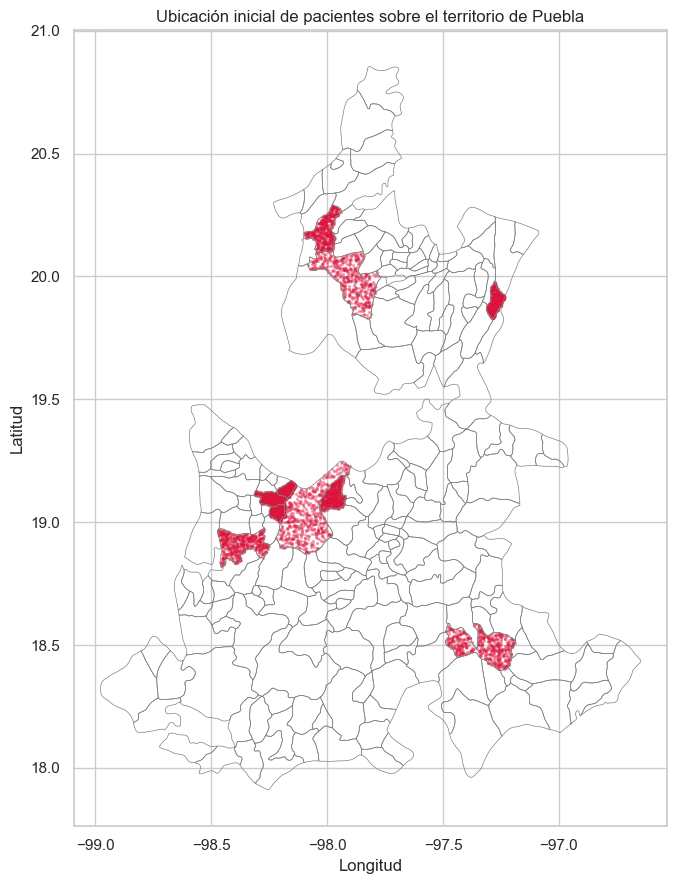

In [10]:
fig, ax = plt.subplots(figsize=(9, 9))
municipios_gdf.boundary.plot(ax=ax, linewidth=0.5, color='gray')
pacientes_gdf.plot(ax=ax, markersize=2, alpha=0.3, color='crimson')
ax.set_title('Ubicación inicial de pacientes sobre el territorio de Puebla')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()


## 4. Unión espacial (Spatial Join)

Se asocia cada paciente con el polígono municipal que lo contiene, generando la etiqueta objetivo `municipio_objetivo`.

In [11]:
pacientes_join = gpd.sjoin(pacientes_gdf, municipios_gdf, how='left', predicate='within')
pacientes_join = pacientes_join.rename(columns={'municipio_poligono': 'municipio_objetivo'})
pacientes_join = pacientes_join.drop(columns=['index_right'])

print("Pacientes sin municipio asignado (fuera de todos los polígonos):",
      pacientes_join['municipio_objetivo'].isnull().sum())

pacientes_join[['ID_Paciente', 'Municipio', 'municipio_objetivo', 'Latitud', 'Longitud']].head(10)


Pacientes sin municipio asignado (fuera de todos los polígonos): 0


,ID_Paciente,Municipio,municipio_objetivo,Latitud,Longitud
0,1,Tehuacán,Tehuacán,18.511587,-97.267586
1,2,San Pedro Cholula,San Pedro Cholula,19.120649,-98.305600
2,3,San Andrés Cholula,San Andrés Cholula,19.051854,-98.207348
3,4,Atlixco,Atlixco,18.969397,-98.467407
4,5,Puebla,Puebla,18.939616,-98.163867
5,6,Zacatlán,Zacatlán,19.866934,-97.890062
6,7,Cuautlancingo,Cuautlancingo,19.124090,-98.191369
7,8,San Andrés Cholula,San Andrés Cholula,19.057317,-98.217389
8,9,Teziutlán,Teziutlán,19.839934,-97.287299
9,10,San Andrés Cholula,San Andrés Cholula,19.032868,-98.201594


In [12]:
# Validación: comparar la etiqueta original 'Municipio' contra 'municipio_objetivo'
# obtenida por unión espacial (deberían coincidir en la gran mayoría de los casos)
coincidencias = (pacientes_join['Municipio'] == pacientes_join['municipio_objetivo']).mean() * 100
print(f"Coincidencia entre Municipio original y municipio_objetivo (unión espacial): {coincidencias:.2f}%")


Coincidencia entre Municipio original y municipio_objetivo (unión espacial): 100.00%


## 5. Separar variable objetivo de las variables predictoras

**Importante:** el dataset de modelado utilizado para entrenar el clasificador **no debe** incluir columnas como `Municipio`, `Localidad` o `Region`. Únicamente se usan `Latitud` y `Longitud` como variables `X`, y `municipio_objetivo` (obtenida por unión espacial) como variable `y`.

In [13]:
dataset_modelado = pacientes_join[['Latitud', 'Longitud', 'municipio_objetivo']].dropna().reset_index(drop=True)

# Confirmar que ninguna columna de ubicación directa está entre los predictores
columnas_prohibidas = {'Municipio', 'Localidad', 'Region', 'municipio_objetivo'}
X = dataset_modelado[['Latitud', 'Longitud']]
y = dataset_modelado['municipio_objetivo']

assert not columnas_prohibidas.intersection(set(X.columns)), "El modelo no debe usar etiquetas de ubicación como entrada"
print("Variables predictoras (X):", list(X.columns))
print("Variable objetivo (y): municipio_objetivo")
print(f"\nTotal de registros para modelado: {len(dataset_modelado)}")
dataset_modelado.head()


Variables predictoras (X): ['Latitud', 'Longitud']
Variable objetivo (y): municipio_objetivo

Total de registros para modelado: 5000


,Latitud,Longitud,municipio_objetivo
0,18.511587,-97.267586,Tehuacán
1,19.120649,-98.305600,San Pedro Cholula
2,19.051854,-98.207348,San Andrés Cholula
3,18.969397,-98.467407,Atlixco
4,18.939616,-98.163867,Puebla


## 6. Distribución de pacientes por municipio (según unión espacial)

In [14]:
conteo_municipios = dataset_modelado['municipio_objetivo'].value_counts()
print("Ranking de municipios con MAYOR concentración de pacientes:")
print(conteo_municipios.head(10))
print("\nMunicipios con MENOR concentración de pacientes (dentro de los presentes):")
print(conteo_municipios.tail(10))


Ranking de municipios con MAYOR concentración de pacientes:
municipio_objetivo
Amozoc                539
San Andrés Cholula    537
Atlixco               528
Tehuacán              515
Huauchinango          501
Puebla                493
Cuautlancingo         486
San Pedro Cholula     481
Zacatlán              465
Teziutlán             455
Name: count, dtype: int64

Municipios con MENOR concentración de pacientes (dentro de los presentes):
municipio_objetivo
Amozoc                539
San Andrés Cholula    537
Atlixco               528
Tehuacán              515
Huauchinango          501
Puebla                493
Cuautlancingo         486
San Pedro Cholula     481
Zacatlán              465
Teziutlán             455
Name: count, dtype: int64


C:\Users\jesus\AppData\Local\Temp\ipykernel_33548\3339260433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_municipios.values, y=conteo_municipios.index, palette='viridis')


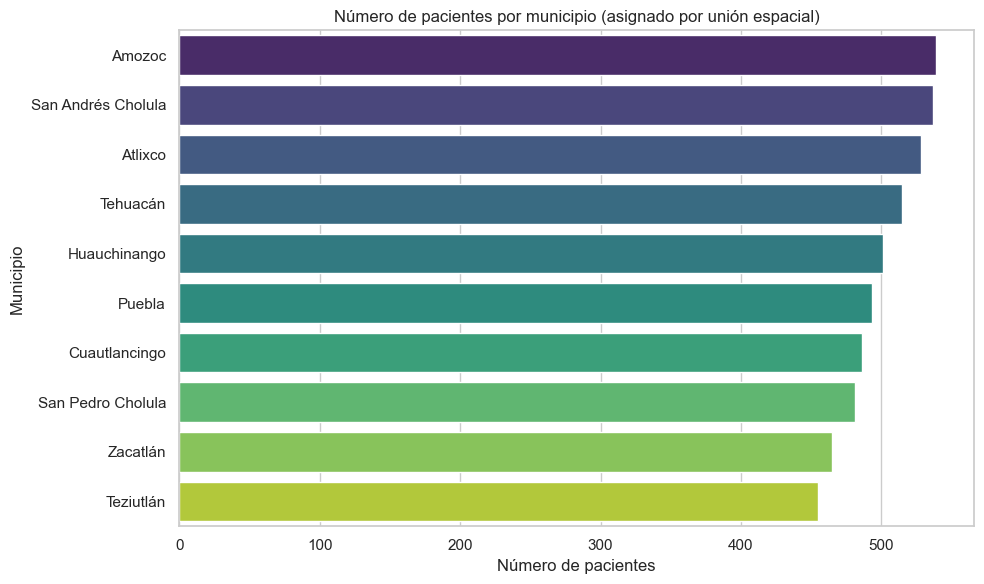

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_municipios.values, y=conteo_municipios.index, palette='viridis')
plt.title('Número de pacientes por municipio (asignado por unión espacial)')
plt.xlabel('Número de pacientes')
plt.ylabel('Municipio')
plt.tight_layout()
plt.show()


## 7. Mapas interactivos con Folium

Se construyen tres visualizaciones: mapa de puntos, mapa de calor (heatmap) y mapa coroplético por municipio.

In [16]:
import folium
from folium.plugins import HeatMap, MarkerCluster

centro_puebla = [19.05, -98.0]


In [17]:
mapa_puntos = folium.Map(location=centro_puebla, zoom_start=8, tiles='CartoDB positron')
cluster = MarkerCluster().add_to(mapa_puntos)

for _, row in dataset_modelado.sample(min(1500, len(dataset_modelado)), random_state=1).iterrows():
    folium.CircleMarker(
        location=[row['Latitud'], row['Longitud']],
        radius=2, color='crimson', fill=True, fill_opacity=0.6
    ).add_to(cluster)

mapa_puntos


### 7.2 Heatmap de concentración de pacientes

In [18]:
mapa_heatmap = folium.Map(location=centro_puebla, zoom_start=8, tiles='CartoDB dark_matter')

puntos_heat = dataset_modelado[['Latitud', 'Longitud']].values.tolist()
HeatMap(puntos_heat, radius=12, blur=15, min_opacity=0.3, max_zoom=10).add_to(mapa_heatmap)

mapa_heatmap


### 7.3 Capa de polígonos municipales sobre el mapa

In [19]:
mapa_poligonos = folium.Map(location=centro_puebla, zoom_start=8, tiles='CartoDB positron')

folium.GeoJson(
    municipios_gdf,
    style_function=lambda feat: {'color': 'gray', 'weight': 0.6, 'fillOpacity': 0}
).add_to(mapa_poligonos)

for _, row in dataset_modelado.sample(min(1000, len(dataset_modelado)), random_state=1).iterrows():
    folium.CircleMarker(
        location=[row['Latitud'], row['Longitud']],
        radius=1.5, color='#1f77b4', fill=True, fill_opacity=0.6
    ).add_to(mapa_poligonos)

mapa_poligonos


### 7.4 Mapa coroplético por municipio (número de pacientes)

In [20]:
conteo_df = conteo_municipios.reset_index()
conteo_df.columns = ['municipio', 'num_pacientes']

mapa_coropletico = folium.Map(location=centro_puebla, zoom_start=8, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=municipios_gdf,
    data=conteo_df,
    columns=['municipio', 'num_pacientes'],
    key_on='feature.properties.municipio_poligono',
    fill_color='YlOrRd',
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name='Número de pacientes por municipio',
    nan_fill_color='white'
).add_to(mapa_coropletico)

mapa_coropletico
